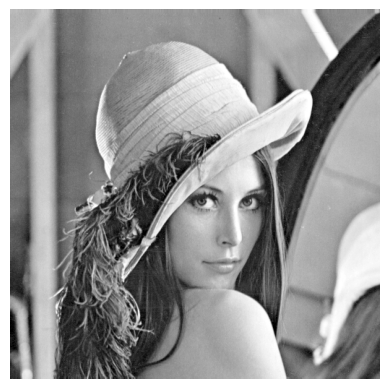

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

from FAST_Keypoint_Detector import fast_keypoint_image
from Harris_Keypoint_Detector import harris_keypoint_image
from Hessian_Keypoint_Detector import hessian_keypoint_image
from Laplacian_Keypoint_Detector import laplacian_keypoint_image

path = 'lena.png'

img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

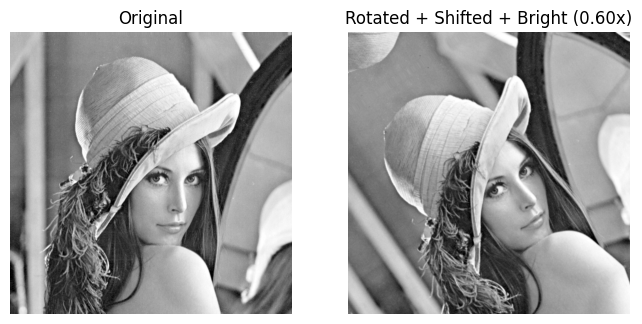

In [33]:
# Random rotation, shift, and brightness on Lena
if img is None:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

h, w = img.shape[:2]
angle = 34
tx = -3
ty = 29
brightness = 0.6

M_rot = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)
M_combo = M_rot.copy()
M_combo[0, 2] += tx
M_combo[1, 2] += ty
rot_shift = cv2.warpAffine(
    img,
    M_combo,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_REFLECT,
 )

rot_shift_bright = np.clip(rot_shift.astype(np.float32) * brightness, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rot_shift_bright, cmap='gray')
plt.title(f'Rotated + Shifted + Bright ({brightness:.2f}x)')
plt.axis('off')

plt.show()

In [41]:
def visualize(images, titles=None):
    count = len(images)
    plt.figure(figsize=(4 * count, 4))

    for idx, img_item in enumerate(images, start=1):
        plt.subplot(1, count, idx)
        if img_item.ndim == 2:
            plt.imshow(img_item, cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(img_item)
        if titles and idx - 1 < len(titles):
            plt.title(titles[idx - 1])
        plt.axis('off')

    plt.show()

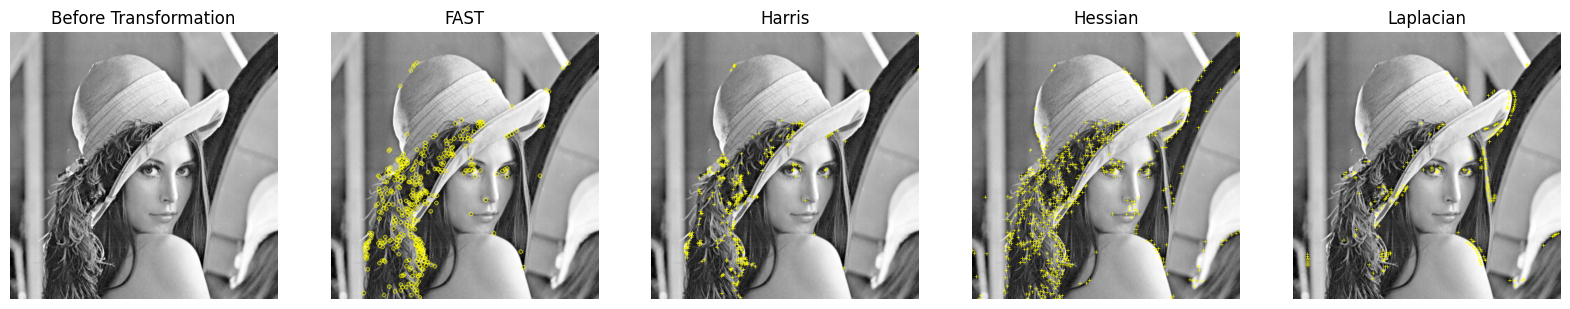

In [42]:
results = [
    img,
    fast_keypoint_image(img),
    harris_keypoint_image(img),
    hessian_keypoint_image(img),
    laplacian_keypoint_image(img),
]
titles = ["Before Transformation","FAST", "Harris", "Hessian", "Laplacian"]
visualize(results, titles)

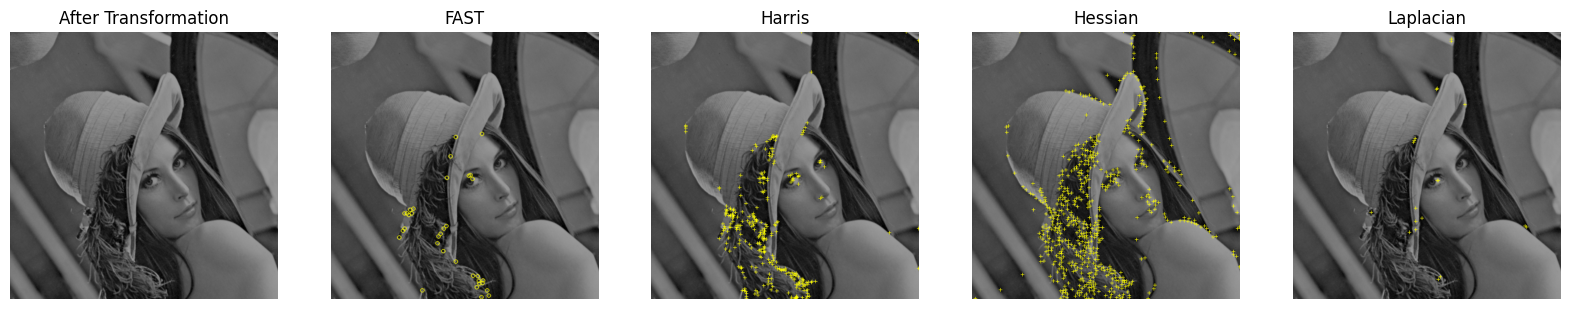

In [43]:
results = [
    rot_shift_bright,
    fast_keypoint_image(rot_shift_bright),
    harris_keypoint_image(rot_shift_bright),
    hessian_keypoint_image(rot_shift_bright),
    laplacian_keypoint_image(rot_shift_bright),
]
titles = ["After Transformation","FAST", "Harris", "Hessian", "Laplacian"]
visualize(results, titles)